In [63]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, roc_auc_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

## EXER 1
### 1.	Load and inspect the German Credit dataset. Check the shape, columns, first five records, and missing values. 

In [81]:
df = pd.read_csv("German Credit Data.csv")
df.shape

(1000, 14)

In [82]:
df.columns.tolist()

['checkin_acc',
 'duration',
 'credit_history',
 'amount',
 'savings_acc',
 'present_emp_since',
 'inst_rate',
 'personal_status',
 'residing_since',
 'age',
 'inst_plans',
 'num_credits',
 'job',
 'status']

In [83]:
df.head()

,checkin_acc,duration,credit_history,amount,savings_acc,present_emp_since,inst_rate,personal_status,residing_since,age,inst_plans,num_credits,job,status
0,A11,6,A34,1169,A65,A75,4,A93,4,67,A143,2,A173,0
1,A12,48,A32,5951,A61,A73,2,A92,2,22,A143,1,A173,1
2,A14,12,A34,2096,A61,A74,2,A93,3,49,A143,1,A172,0
3,A11,42,A32,7882,A61,A74,2,A93,4,45,A143,1,A173,0
4,A11,24,A33,4870,A61,A73,3,A93,4,53,A143,2,A173,1


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   checkin_acc        1000 non-null   object
 1   duration           1000 non-null   int64 
 2   credit_history     1000 non-null   object
 3   amount             1000 non-null   int64 
 4   savings_acc        1000 non-null   object
 5   present_emp_since  1000 non-null   object
 6   inst_rate          1000 non-null   int64 
 7   personal_status    1000 non-null   object
 8   residing_since     1000 non-null   int64 
 9   age                1000 non-null   int64 
 10  inst_plans         1000 non-null   object
 11  num_credits        1000 non-null   int64 
 12  job                1000 non-null   object
 13  status             1000 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 109.5+ KB


### 2.	Encode the categorical attributes and split the dataset into training and testing sets in the ratio 70:30. 

In [85]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('status', axis=1)
y = df_encoded['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=27)

### 3.	Apply a Decision Tree classifier and use GridSearchCV to determine the optimal criterion (gini or entropy) and max_depth (2–10) using 10-fold cross-validation and ROC-AUC scoring. 

In [86]:

dt_classifier = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 11)  # Evaluates depths from 2 to 10 inclusive
}

grid_search = GridSearchCV(
    estimator=dt_classifier,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=10,
    n_jobs=-1,       
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_roc_auc = best_model.score(X_test, y_test)

Best Parameters: {'criterion': 'gini', 'max_depth': 3}
Best Cross-Validation ROC-AUC Score: 0.7205


### 4.	Display and interpret the text representation of the rules learned by the optimal Decision Tree. 

In [87]:
best_tree = grid_search.best_estimator_

tree_rules = export_text(best_tree, feature_names=list(X_train.columns))
print(tree_rules)

|--- checkin_acc_A14 <= 0.50
|   |--- duration <= 31.50
|   |   |--- credit_history_A31 <= 0.50
|   |   |   |--- class: 0
|   |   |--- credit_history_A31 >  0.50
|   |   |   |--- class: 1
|   |--- duration >  31.50
|   |   |--- age <= 29.50
|   |   |   |--- class: 1
|   |   |--- age >  29.50
|   |   |   |--- class: 1
|--- checkin_acc_A14 >  0.50
|   |--- inst_plans_A143 <= 0.50
|   |   |--- age <= 44.50
|   |   |   |--- class: 0
|   |   |--- age >  44.50
|   |   |   |--- class: 0
|   |--- inst_plans_A143 >  0.50
|   |   |--- age <= 22.50
|   |   |   |--- class: 0
|   |   |--- age >  22.50
|   |   |   |--- class: 0



Here, there are two branches:

Branch 1: 
- the root node has the condition `checkin_acc_A14 <= 0.50` i.e. Applicant does not have category A14 check in account. Then moves to check if `duration <= 31.50` months, if true then checks if `credit_history_A31 <= 0.50` then marks the applicant as Class 0 (Low Risk) if the condition satisfies, else marks as Class 1 (High Risk).
- if `duration >= 31.50`, then checks if `age <= 29.50`, if true marks the applicant as Class 1 (High Risk), else still marks the applicant as Class 1 (High Risk).

Branch 2:
- if the Applicant does have a category A14 check in account i.e. `checkin_acc_A14 >  0.50` it then checks if `inst_plans_A143 <= 0.50`, if true checks `age <= 44.50`, marks applicant as Class 0 if true. if false, regardless marks applicant as Class 0.
- If `inst_plans_A143 >  0.50`, then checks if `age <= 22.50`, if true marks applicant as Class 0, even if false marks applicant as Class 0.

### 5.	Evaluate the optimal Decision Tree using test accuracy, confusion matrix, and classification report. 

In [88]:
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}\n")

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
print("\n")

class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

Test Accuracy: 0.6967

Confusion Matrix:
[[190  19]
 [ 72  19]]


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.91      0.81       209
           1       0.50      0.21      0.29        91

    accuracy                           0.70       300
   macro avg       0.61      0.56      0.55       300
weighted avg       0.66      0.70      0.65       300



### 6.	Calculate and interpret the ROC-AUC score of the optimal Decision Tree on the test dataset. 

In [89]:
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 2. Calculate the test ROC-AUC score
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test ROC-AUC Score: {test_roc_auc:.4f}")

Test ROC-AUC Score: 0.6437


A test ROC-AUC score of 0.6437 indicates that model has a moderate ability to distinguish between good and bad credit risks on unseen data.  it performs better than random guessing (0.50)

### 7.	Determine and interpret the feature importance obtained from the optimal Decision Tree.

Feature Importances:
checkin_acc_A14       0.559797
duration              0.187308
age                   0.114359
credit_history_A31    0.086590
inst_plans_A143       0.051947
dtype: float64


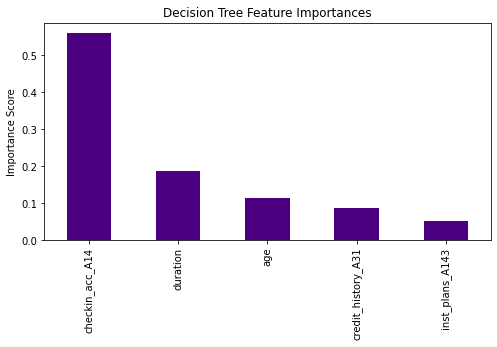

In [92]:
importances = best_tree.feature_importances_

feature_importance_df = pd.Series(importances, index=X_train.columns)

feature_importance_df = feature_importance_df[feature_importance_df > 0].sort_values(ascending=False)

print("Feature Importances:")
print(feature_importance_df)

plt.figure(figsize=(8, 4))
feature_importance_df.plot(kind='bar', color='indigo')
plt.title('Decision Tree Feature Importances')
plt.ylabel('Importance Score')
plt.show()

# EXER 2
### 1.	Load and inspect the Fuel Consumption dataset. Display its shape, columns, first five records, and check for missing values in the required attributes

In [47]:
df2 = pd.read_csv("FuelConsumption.csv")
df2.shape

(1067, 13)

In [48]:
df2.columns.tolist()

['MODELYEAR',
 'MAKE',
 'MODEL',
 'VEHICLECLASS',
 'ENGINESIZE',
 'CYLINDERS',
 'TRANSMISSION',
 'FUELTYPE',
 'FUELCONSUMPTION_CITY',
 'FUELCONSUMPTION_HWY',
 'FUELCONSUMPTION_COMB',
 'FUELCONSUMPTION_COMB_MPG',
 'CO2EMISSIONS']

In [49]:
df2.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [50]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


### 2.	Select ENGINESIZE, CYLINDERS, FUELCONSUMPTION_COMB, and CO2EMISSIONS, and plot CO₂ emissions with respect to engine size. Interpret the relationship. 

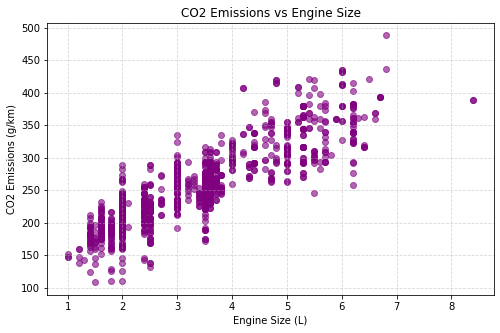

In [52]:
selected_columns = [
    'ENGINESIZE',
    'CYLINDERS',
    'FUELCONSUMPTION_COMB',
    'CO2EMISSIONS',
]
df2_subset = df2[selected_columns]

plt.figure(figsize=(8, 5))
plt.scatter(
    df2_subset['ENGINESIZE'],
    df2_subset['CO2EMISSIONS'],
    color='purple',
    alpha=0.6,
)
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.title('CO2 Emissions vs Engine Size')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The scatter plot reveals a clear positive linear (or near-linear) trend. As the engine size (ENGINESIZE) increases, the CO₂ emissions (CO2EMISSIONS) consistently increase as well.

### 3.	Prepare engine size and CO₂ emissions for modeling and split the dataset into training and testing sets in the ratio 70:30. 

In [57]:
X = df2[['ENGINESIZE']]
y = df2['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=27
)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (746, 1), (746,)
Testing set shape: (321, 1), (321,)


### 4.	Develop polynomial regression models of degrees 3, 4, and 5 and evaluate them using Mean Absolute Error, Residual Sum of Squares, and R² score

In [64]:
degrees = [3, 4, 5]
evaluation_results = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    
    y_pred = poly_model.predict(X_test_poly)
    
    mae = mean_absolute_error(y_test, y_pred)
    rss = np.sum((y_test - y_pred) ** 2)
    r2 = r2_score(y_test, y_pred)
    
    evaluation_results[degree] = {'MAE': mae, 'RSS': rss, 'R2': r2}
    
    print(f"--- Degree {degree} Polynomial Regression ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Residual Sum of Squares (RSS): {rss:.4f}")
    print(f"R² Score: {r2:.4f}\n")

--- Degree 3 Polynomial Regression ---
Mean Absolute Error (MAE): 23.9302
Residual Sum of Squares (RSS): 328037.7719
R² Score: 0.7674

--- Degree 4 Polynomial Regression ---
Mean Absolute Error (MAE): 23.9313
Residual Sum of Squares (RSS): 328794.9185
R² Score: 0.7668

--- Degree 5 Polynomial Regression ---
Mean Absolute Error (MAE): 23.8845
Residual Sum of Squares (RSS): 328661.6445
R² Score: 0.7669



### 5.	Compare the polynomial regression models and determine the best model based on the evaluation metrics. 

Degree 3 Polynomial Regression is the best choice.

### 6.	Use the best polynomial regression model to predict CO₂ emissions for an unknown engine size of 2.0 litres. 

In [65]:
best_degree = 3
poly_best = PolynomialFeatures(degree=best_degree)

X_train_poly = poly_best.fit_transform(X_train)
best_poly_model = LinearRegression()
best_poly_model.fit(X_train_poly, y_train)

engine_size_unknown = np.array([[2.0]])

X_unknown_poly = poly_best.transform(engine_size_unknown)

predicted_co2 = best_poly_model.predict(X_unknown_poly)

print(f"Predicted CO₂ Emissions for a 2.0L engine: {predicted_co2[0]:.2f} g/km")

Predicted CO₂ Emissions for a 2.0L engine: 202.17 g/km


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


### 7.	Plot the best polynomial regression curve along with the actual CO₂ emission observations and interpret the result.

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


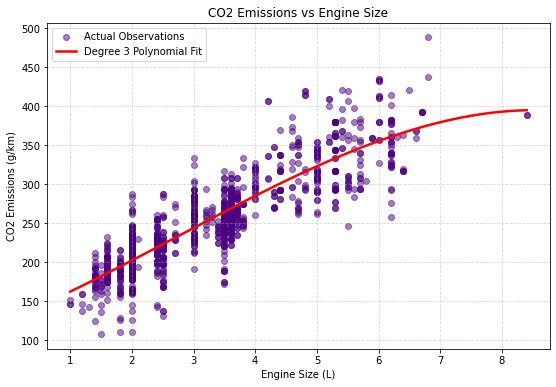

In [77]:
x_range = np.linspace(X['ENGINESIZE'].min(), X['ENGINESIZE'].max(), 300).reshape(-1, 1)

x_range_poly = poly_best.transform(x_range)

y_range_pred = best_poly_model.predict(x_range_poly)

plt.figure(figsize=(9, 6))
plt.scatter(X, y, color='indigo', alpha=0.5, label='Actual Observations')
plt.plot(x_range, y_range_pred, color='red', linewidth=2.5, label='Degree 3 Polynomial Fit')

plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.title('CO2 Emissions vs Engine Size')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()